<a href="https://colab.research.google.com/github/yemioz/Operations_Research_Projects/blob/main/linear-and-exponential-regression.ipynb" target="_parent"><img src="https://colab.research.google.com/assets/colab-badge.svg" alt="Open In Colab"/></a>

# Regression

This notebook implements both multiple and exponential regression with secant method approximation for $b$ parameter in exponential regression.

In [20]:
import numpy as np
import pandas as pd
import matplotlib.pyplot as plt

In [21]:
# Linear Regression fit
data = "https://raw.githubusercontent.com/nurfnick/Data_Sets_For_Stats/master/CuratedDataSets/hockey.csv"
df = pd.read_csv(data)
df.head()

,Rk,Player,Age,Tm,Pos,GP,G,A,PTS,+/-,...,SH.1,S,S%,TOI,ATOI,BLK,HIT,FOW,FOL,FO%
0,1,Justin Abdelkader\abdelju01,31,DET,LW,71,6,13,19,-14,...,0,95,6.3,1093,15:24,34,185,52,51,50.5
1,2,Pontus Aberg\abergpo01,25,TOT,LW,59,12,13,25,-14,...,0,101,11.9,861,14:36,11,45,2,17,10.5
2,2,Pontus Aberg\abergpo01,25,ANA,LW,37,11,8,19,-10,...,0,74,14.9,578,15:37,7,31,2,9,18.2
3,2,Pontus Aberg\abergpo01,25,MIN,LW,22,1,5,6,-4,...,0,27,3.7,283,12:52,4,14,0,8,0.0
4,3,Vitaly Abramov\abramvi01,20,OTT,RW,1,0,0,0,-3,...,0,0,NaN,14,13:52,1,0,0,0,NaN


In [22]:
if len(df['G']) == len(df['PTS']):
  n = len(df['G'])
n

x_col = df['G']
y_col = df['PTS']

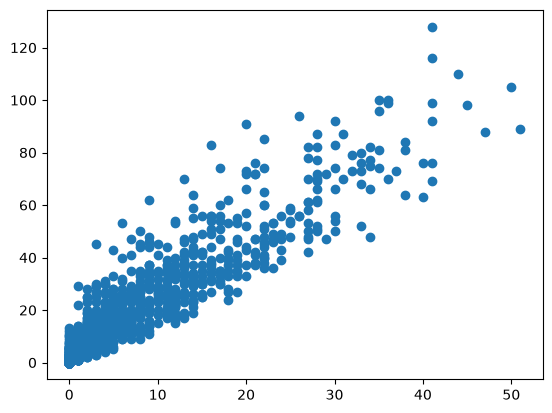

In [23]:
plt.scatter(x_col, y_col)

In [24]:
x_avg = sum(x_col)/n
y_avg = sum(y_col)/n

xy_avg = 0
for i in range(n):
  xy_avg += x_col[i]*y_col[i]
xy_avg /= n

sumsquare = 0
for i in range(n):
  sumsquare += x_col[i]**2
sumsquare /= n

In [25]:
b1 = (xy_avg-x_avg*y_avg)/(sumsquare-x_avg**2)
b0 = y_avg-b1*x_avg

def line(x):
  return b0 + b1*x

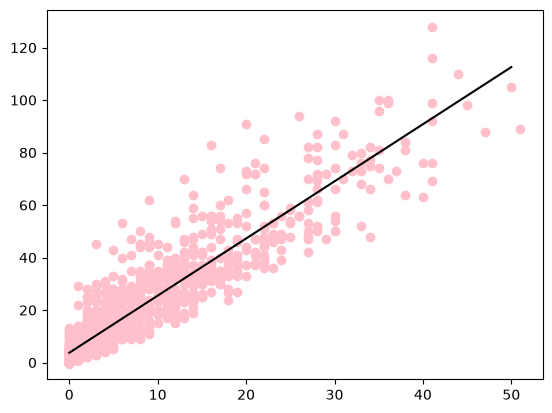

In [26]:
x = np.linspace(0,50)
plt.plot(x, line(x), c='black')
plt.scatter(x_col,y_col, c='pink')

The linear regression model is very accurate. It hits the middle region of the points, as expected.

In [27]:
# Multiple Regression
x = np.column_stack((df['G'], df['A'], np.ones(n)))
Y = df['PTS'].values
print(x)

[[ 6. 13.  1.]
 [12. 13.  1.]
 [11.  8.  1.]
 ...
 [ 0.  3.  1.]
 [ 2.  0.  1.]
 [ 0.  0.  1.]]


In [28]:
inv_matrix = np.linalg.pinv(x.T @ x)
xy_vec = x.T @ Y

print(np.dot(inv_matrix, xy_vec))

[1.00000000e+00 1.00000000e+00 7.10542736e-15]


In [29]:
# My Own Regression
link = 'https://raw.githubusercontent.com/nurfnick/Data_Sets_For_Stats/master/CuratedDataSets/100mOlympicRecords.csv'
data = pd.read_csv(link)
data.head()

,Time,Athlete,Nation,Games,Round,Date,Gender
0,12.2,Francis Lane,United States (USA),1896,Heat 1,1896-04-06,Men
1,12.2,Thomas Curtis,United States (USA),1896,Heat 2,1896-04-06,Men
2,11.8,Tom Burke,United States (USA),1896,Heat 3,1896-04-06,Men
3,11.4,Arthur Duffey,United States (USA),1900,Heat 1,6/14/1900,Men
4,11.4,Walter Tewksbury,United States (USA),1900,Heat 2,6/14/1900,Men


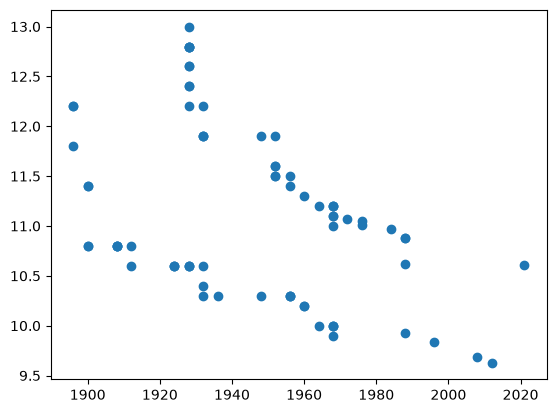

In [30]:
plt.scatter(data['Games'], data['Time'])

<h1> Exponential Regression</h1>

$$y=Ae^{bx}$$

Creating exponential function calculation
$$f(b)=\sum\limits_{i=1}^{n}y_ix_ie^{bx_i}
-\frac{\sum\limits_{i=1}^{n}y_ie^{bx_i}}
{\sum\limits_{i=1}^{n}e^{2bx_i}}
\sum\limits_{i=1}^{n}x_ie^{2bx_i}
=0$$

and
$$A=\frac{\sum\limits_{i=1}^{n}y_ie^{bx_i}}
{\sum\limits_{i=1}^{n}e^{2bx_i}}
$$

In [31]:
def average(list1):
  return sum(list1)/len(list1)

def square_sum(list1, list2):
  sum = 0
  for i in range(len(list1)):
    sum = sum + list1[i]*list2[i]
  return sum

def sum3(list1, list2, list3):
  sum = 0
  for i in range(len(list1)):
    sum = sum + list1[i]*list2[i]*list3[i]
  return sum

In [32]:
function = lambda b: sum3(data['Time'],data['Games'],np.exp(b*data['Games'])) \
  -square_sum(data['Time'],np.exp(b*data['Games']))/sum(np.exp(2*b*data['Games'])) \
  *square_sum(data['Time'],np.exp(2*b*data['Games']))

Must solve this nonlinear equation for $b$. We will use the secant method.
The below equation is used for the secant method.
$$x_{i+1}=x_i-\frac{f(x_i)(x_i-x_{i-1})}{f(x_i)-f(x_{i-1})}$$
This method requires two initial guesses and typically converges slower than the Newton-Raphson method, which is another approximation method for finding roots of nonlinear equations.

In [33]:
def approx_error(present_approx, previous_approx):
  return present_approx - previous_approx

def relative_error_percent(present_approx, previous_approx):
  return abs(approx_error(previous_approx, present_approx) / present_approx)*100

terations1 = []
error_list = []

def secant(function, guess_one, guess_two):
  root = guess_two - (function(guess_two)*(guess_two - guess_one))/(function(guess_two) - function(guess_one))
  return root

def secant_method(function, first_value, second_value, iterations):
  x = [first_value, second_value]
  for i in range(iterations):
    x.append(secant(function,x[-2],x[-1]))
    error = relative_error_percent(x[-1], x[-2])
    error_list.append(error)
  return x

In [34]:
sec = secant_method(function, 0.00000001, 0.00001, 20)
secant_approx1 = {'First Value': [i for i in sec[:20]]}
secant_approx2 = {'Second Value': [i for i in sec[1:21]]}
secant_approx3 = {'Output': [i for i in sec[2:22]]}
error_approx = {'Error': [i for i in error_list[:20]]}

secant_table1 = pd.DataFrame(secant_approx1)
secant_table2 = pd.DataFrame(secant_approx2)
secant_table3 = pd.DataFrame(secant_approx3)
error_table = pd.DataFrame(error_approx)

result = pd.concat([secant_table1, secant_table2, secant_table3, error_table],axis=1)
print(result)

     First Value  Second Value    Output       Error
0   1.000000e-08      0.000010 -0.000509  101.964074
1   1.000000e-05     -0.000509 -0.000807   36.886809
2  -5.091458e-04     -0.000807 -0.001186   32.007562
3  -8.067185e-04     -0.001186 -0.001534   22.660033
4  -1.186483e-03     -0.001534 -0.001894   19.008380
5  -1.534113e-03     -0.001894 -0.002249   15.795492
6  -1.894163e-03     -0.002249 -0.002607   13.703871
7  -2.249479e-03     -0.002607 -0.002963   12.032647
8  -2.606698e-03     -0.002963 -0.003320   10.749167
9  -2.963256e-03     -0.003320 -0.003677    9.704565
10 -3.320143e-03     -0.003677 -0.004034    8.848228
11 -3.676978e-03     -0.004034 -0.004391    8.129740
12 -4.033908e-03     -0.004391 -0.004748    7.519659
13 -4.390874e-03     -0.004748 -0.005105    6.994673
14 -4.747900e-03     -0.005105 -0.005462    6.538321
15 -5.104977e-03     -0.005462 -0.005819    6.137902
16 -5.462107e-03     -0.005819 -0.006177    5.783751
17 -5.819289e-03     -0.006177 -0.006534    5.

I already suspect that the model will not be a very good fit because my root is 5% accurate, which is pretty high.

The table tells us that using the coefficient $b=0.012850$ will give us an error of $0.03%$. We would show more iterations but python will only print to the 6th decimal place, so that is the best approximation we can find.

Now that we have b, we plug it into A to finish our regression equation.
$$A=\frac{\sum\limits_{i=1}^{n}y_ie^{(-0.007249)x_i}}
{\sum\limits_{i=1}^{n}e^{2(-0.007249)x_i}}
$$

In [35]:
A = lambda b:square_sum(data['Time'],np.exp(b*data['Games']))/sum(np.exp(2*b*data['Games']))
b = -0.007249
A_approx = A(b)

$𝐴=13988122.649566999$

Lets plug this into our regression equation and see how it matches up with the data points!
$$y=13988122.649566999e^{-0.007249x}$$

In [36]:
def exp_line(A, coefficient, points):
  return A*np.exp(coefficient*points)

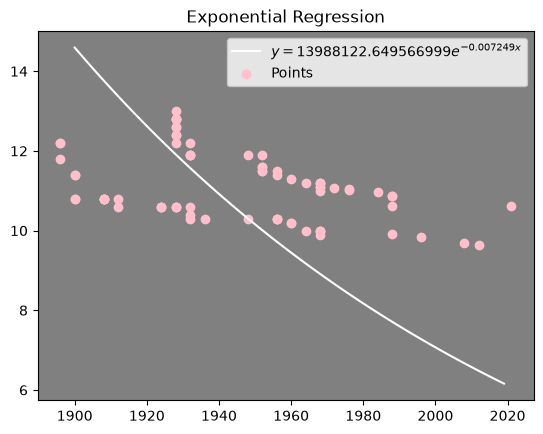

In [37]:
x = np.arange(1900, 2020)
ax = plt.axes()
ax.set_facecolor('grey')
plt.plot(x, exp_line(A_approx, b, x), c='white')
plt.scatter(data['Games'], data['Time'], c='pink')
plt.title('Exponential Regression')
plt.legend(['$y=13988122.649566999e^{-0.007249x}$', 'Points'])

As expected, my model doesn't seem very accurate. It starts on course, but then veers off from the points very fast, and never gets back on track.